
## Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Scikit-learn — preprocessing & model selection
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler

# Classifiers
from sklearn.ensemble import (RandomForestClassifier, BaggingClassifier,
                               AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

# Imbalance handling
from imblearn.over_sampling import SMOTE
from collections import Counter




## Step 1: Exploratory Data Analysis (EDA)


In [2]:
#  1.1 Load Dataset 
df = pd.read_excel('glass.xlsx')   

print(f"Dataset Shape  : {df.shape}")
print(f"Features       : {list(df.columns[:-1])}")
print(f"Target column  : 'Type'")
df.head(8)


Dataset Shape  : (214, 10)
Features       : ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']
Target column  : 'Type'


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.00,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.00,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.00,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.00,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.00,1
5,1.51596,12.79,3.61,1.62,72.97,0.64,8.07,0.0,0.26,1
6,1.51743,13.30,3.60,1.14,73.09,0.58,8.17,0.0,0.00,1
7,1.51756,13.15,3.61,1.05,73.24,0.57,8.24,0.0,0.00,1


In [3]:
#  1.2 Dataset Info & Data Types 
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [4]:
#  1.3 Statistical Summary 
print("Statistical Summary:")
df.describe().round(4)


Statistical Summary:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000
mean,1.5184,13.4079,2.6845,1.4449,72.6509,0.4971,8.9570,0.1750,0.0570,2.7804
std,0.0030,0.8166,1.4424,0.4993,0.7745,0.6522,1.4232,0.4972,0.0974,2.1037
min,1.5112,10.7300,0.0000,0.2900,69.8100,0.0000,5.4300,0.0000,0.0000,1.0000
25%,1.5165,12.9075,2.1150,1.1900,72.2800,0.1225,8.2400,0.0000,0.0000,1.0000
50%,1.5177,13.3000,3.4800,1.3600,72.7900,0.5550,8.6000,0.0000,0.0000,2.0000
75%,1.5192,13.8250,3.6000,1.6300,73.0875,0.6100,9.1725,0.0000,0.1000,3.0000
max,1.5339,17.3800,4.4900,3.5000,75.4100,6.2100,16.1900,3.1500,0.5100,7.0000


In [5]:
#  1.4 Missing Values 
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
if missing.sum() == 0:
    print("No missing values found — dataset is complete!")


Missing values per column:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Total missing values: 0
No missing values found — dataset is complete!


In [ ]:
#  1.4b Missing Value Imputation Strategy (Demonstration) 
# The Glass dataset itself has 0 missing values (confirmed above), so no imputation
# is strictly required. To explicitly demonstrate the chosen imputation strategy
# (median imputation) as required by the assignment, we inject a small percentage
# of missing values into a COPY of the data and show that SimpleImputer recovers it.
from sklearn.impute import SimpleImputer

np.random.seed(42)
X_demo = df[features].copy()
missing_mask = np.random.rand(*X_demo.shape) < 0.03   # ~3% missing, injected for demo only
X_demo_missing = X_demo.mask(missing_mask)

print("Injected missing values per column (demo only):")
print(X_demo_missing.isnull().sum())

# Strategy: median imputation — robust to outliers/skew, which several Glass features exhibit
imputer = SimpleImputer(strategy='median')
X_demo_imputed = pd.DataFrame(imputer.fit_transform(X_demo_missing), columns=features)

print(f"\nMissing values after median imputation: {X_demo_imputed.isnull().sum().sum()}")

# Apply the same imputer to the REAL feature matrix used downstream.
# Since the real data has no missing values, this is a safe no-op that keeps the
# pipeline robust in case missing values appear in future data.
imputer_real = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer_real.fit_transform(df[features]), columns=features)
print("No-op confirmed on real data:", np.allclose(df[features].values, X_imputed.values))

Injected missing values per column (demo only):
RI    6
Na    8
Mg    9
Al    4
Si    7
K     7
Ca    4
Ba    6
Fe    6
dtype: int64

Missing values after median imputation: 0
No-op confirmed on real data: True


Class Distribution:
  Type 1 (Building Float        ):  70 samples  ██████████████████████████████████████████████████████████████████████
  Type 2 (Building Non-Float    ):  76 samples  ████████████████████████████████████████████████████████████████████████████
  Type 3 (Vehicle Float         ):  17 samples  █████████████████
  Type 5 (Containers            ):  13 samples  █████████████
  Type 6 (Tableware             ):   9 samples  █████████
  Type 7 (Headlamps             ):  29 samples  █████████████████████████████

Majority class: Type 2 → 76 samples
Minority class: Type 6 → 9 samples
Imbalance ratio: 8.4x


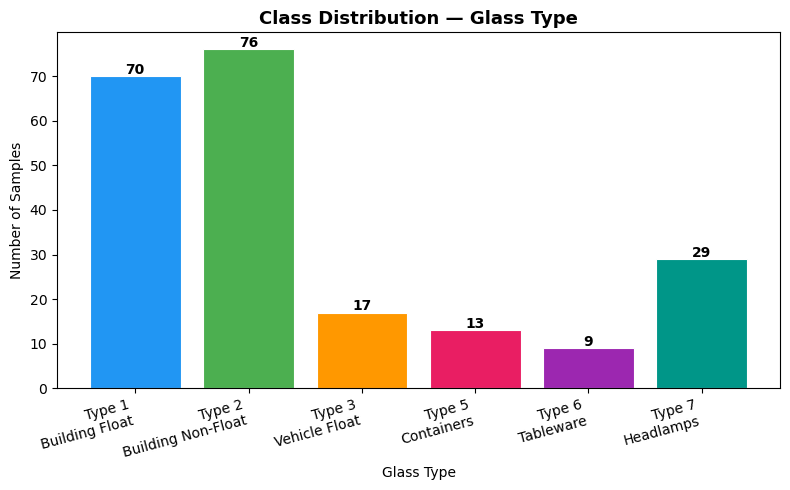

In [8]:
#  1.5 Target Class Distribution (Imbalance Check) 
type_labels = {1:'Building Float', 2:'Building Non-Float',
               3:'Vehicle Float', 5:'Containers', 6:'Tableware', 7:'Headlamps'}

class_counts = df['Type'].value_counts().sort_index()
print("Class Distribution:")
for t, cnt in class_counts.items():
    bar = '█' * cnt
    print(f"  Type {t} ({type_labels[t]:<22}): {cnt:>3} samples  {bar}")

print(f"\nMajority class: Type {class_counts.idxmax()} → {class_counts.max()} samples")
print(f"Minority class: Type {class_counts.idxmin()} → {class_counts.min()} samples")
print(f"Imbalance ratio: {class_counts.max()/class_counts.min():.1f}x")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#009688']
bars = ax.bar([f"Type {t}\n{type_labels[t]}" for t in class_counts.index],
              class_counts.values, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Class Distribution — Glass Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Samples')
ax.set_xlabel('Glass Type')
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


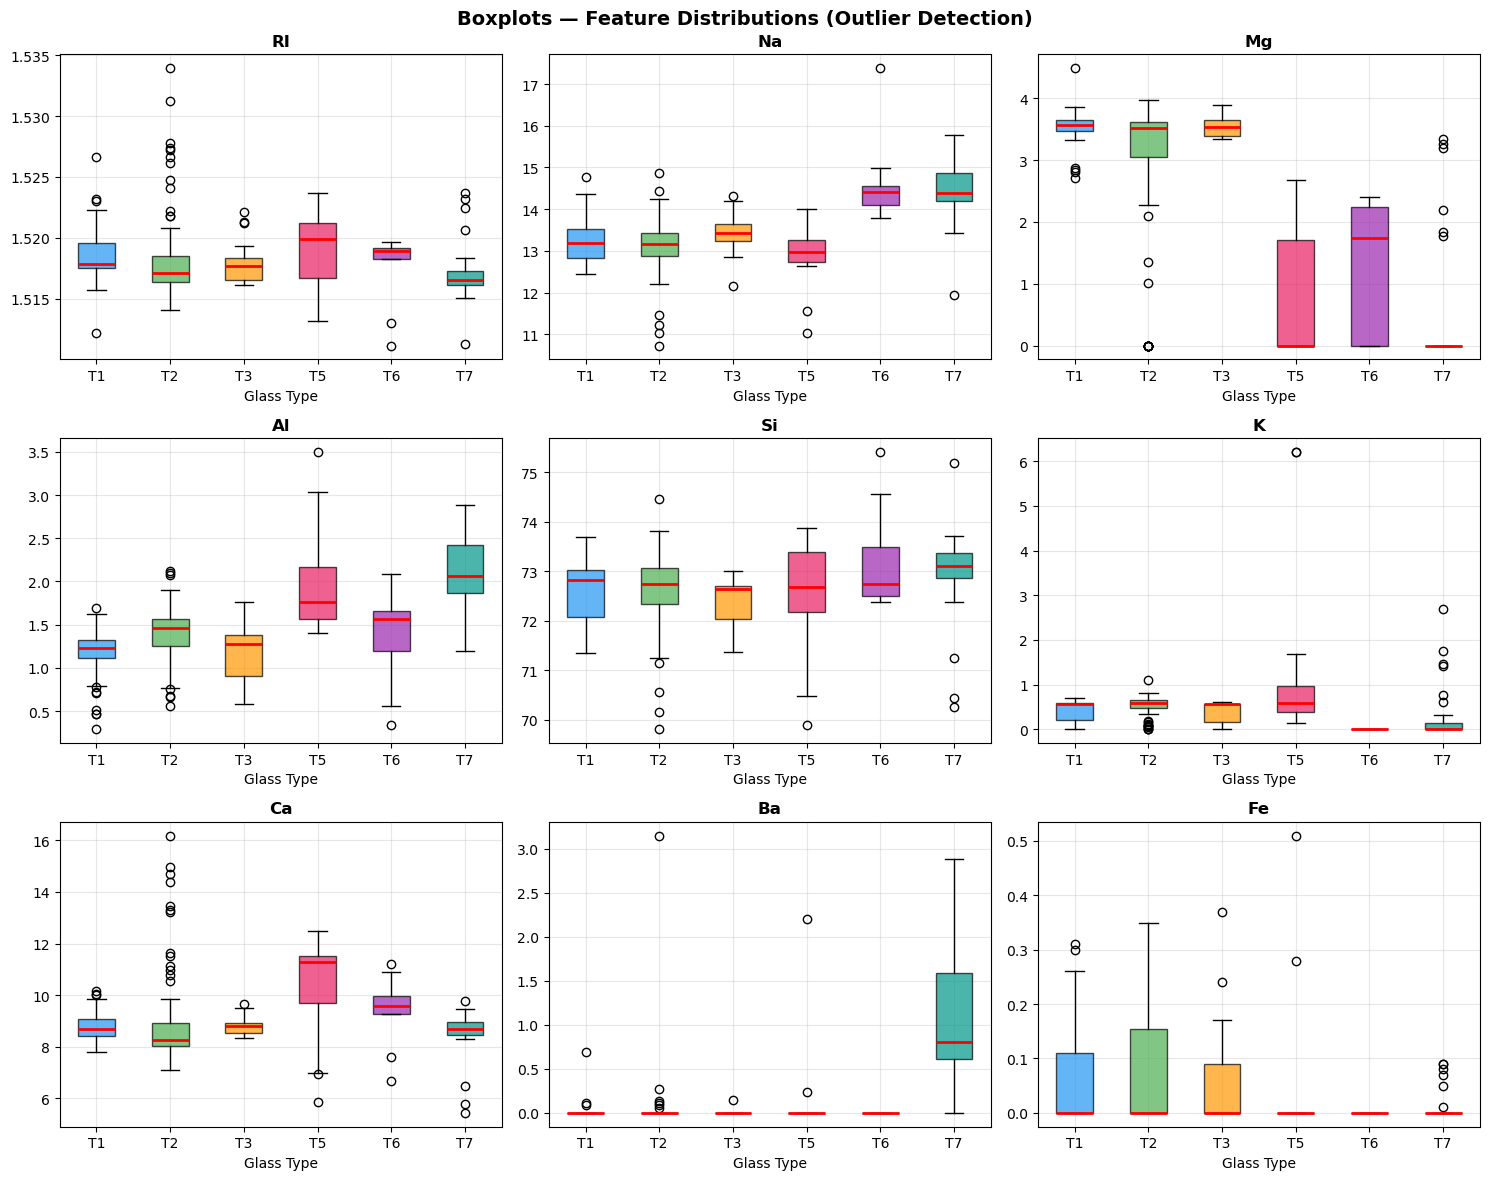

 Observation: Ba and Fe show many outliers (near-zero values for most classes).
   K also shows outliers. These are real chemical measurements, not data errors.


In [9]:
#  1.6 Outlier Detection — Boxplots 
features = df.columns[:-1].tolist()   # All except 'Type'

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Boxplots — Feature Distributions (Outlier Detection)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    data_by_class = [df[df['Type']==t][feat].values for t in sorted(df['Type'].unique())]
    bp = ax.boxplot(data_by_class, patch_artist=True,
                    medianprops=dict(color='red', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat, fontweight='bold')
    ax.set_xticklabels([f'T{t}' for t in sorted(df['Type'].unique())])
    ax.set_xlabel('Glass Type')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(" Observation: Ba and Fe show many outliers (near-zero values for most classes).")
print("   K also shows outliers. These are real chemical measurements, not data errors.")


---
## Step 2: Data Visualization
Histograms, pair plots, and correlation analysis.


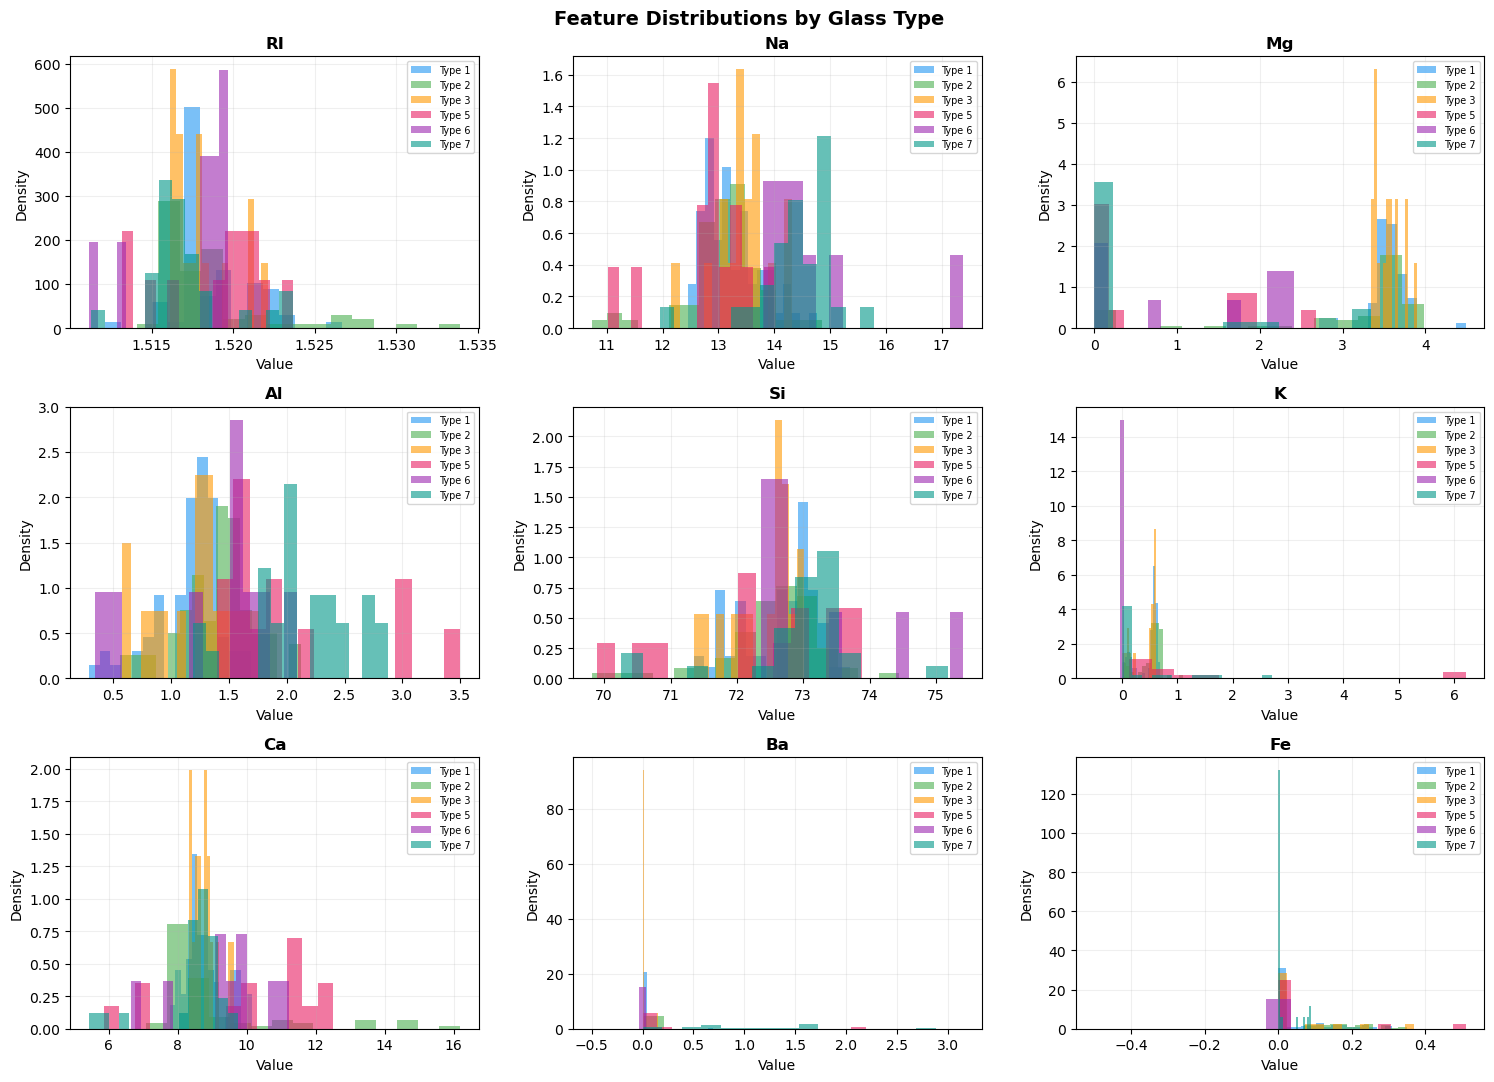

 Mg, Ba, and Al show good class separation — likely important features for RF.


In [10]:
#  2.1 Feature Histograms 
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle('Feature Distributions by Glass Type', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    for j, t in enumerate(sorted(df['Type'].unique())):
        ax.hist(df[df['Type']==t][feat], bins=15, alpha=0.6,
                color=colors[j], label=f'Type {t}', density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()
print(" Mg, Ba, and Al show good class separation — likely important features for RF.")


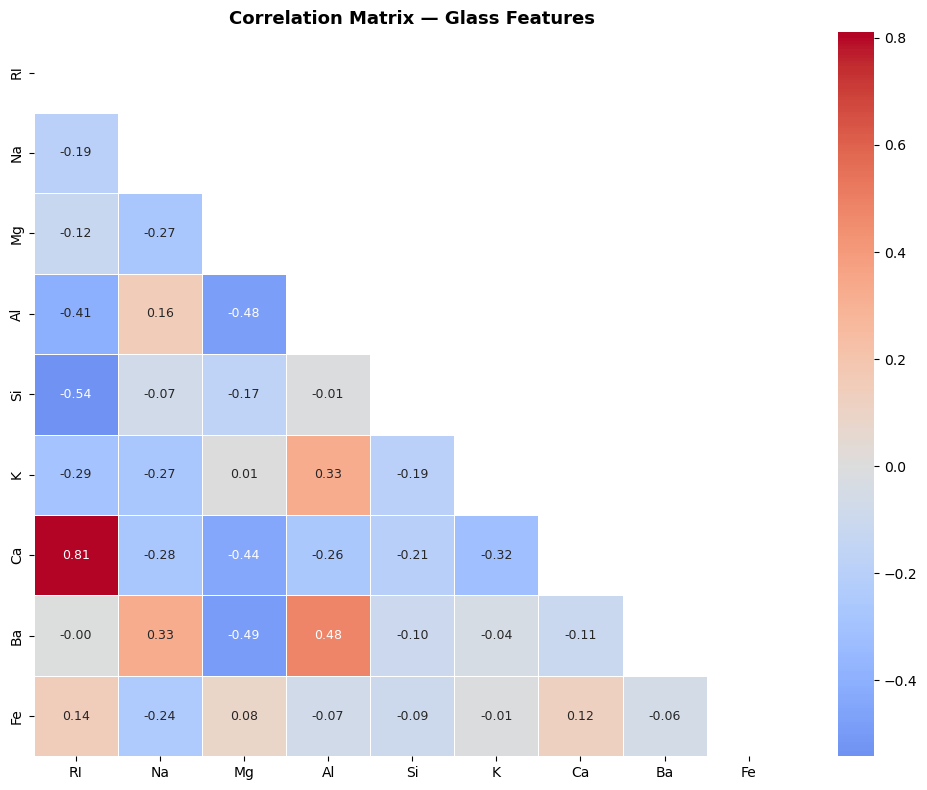

Top correlated pairs:
  Ca ↔ RI: 0.810
  Si ↔ RI: 0.542
  Ba ↔ Mg: 0.492
  Al ↔ Mg: 0.482
  Ba ↔ Al: 0.479


In [11]:
#  2.2 Correlation Heatmap 
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Glass Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top correlated pairs:")
corr_pairs = (corr.abs().where(~mask).stack()
              .sort_values(ascending=False).head(5))
for (a, b), v in corr_pairs.items():
    print(f"  {a} ↔ {b}: {v:.3f}")


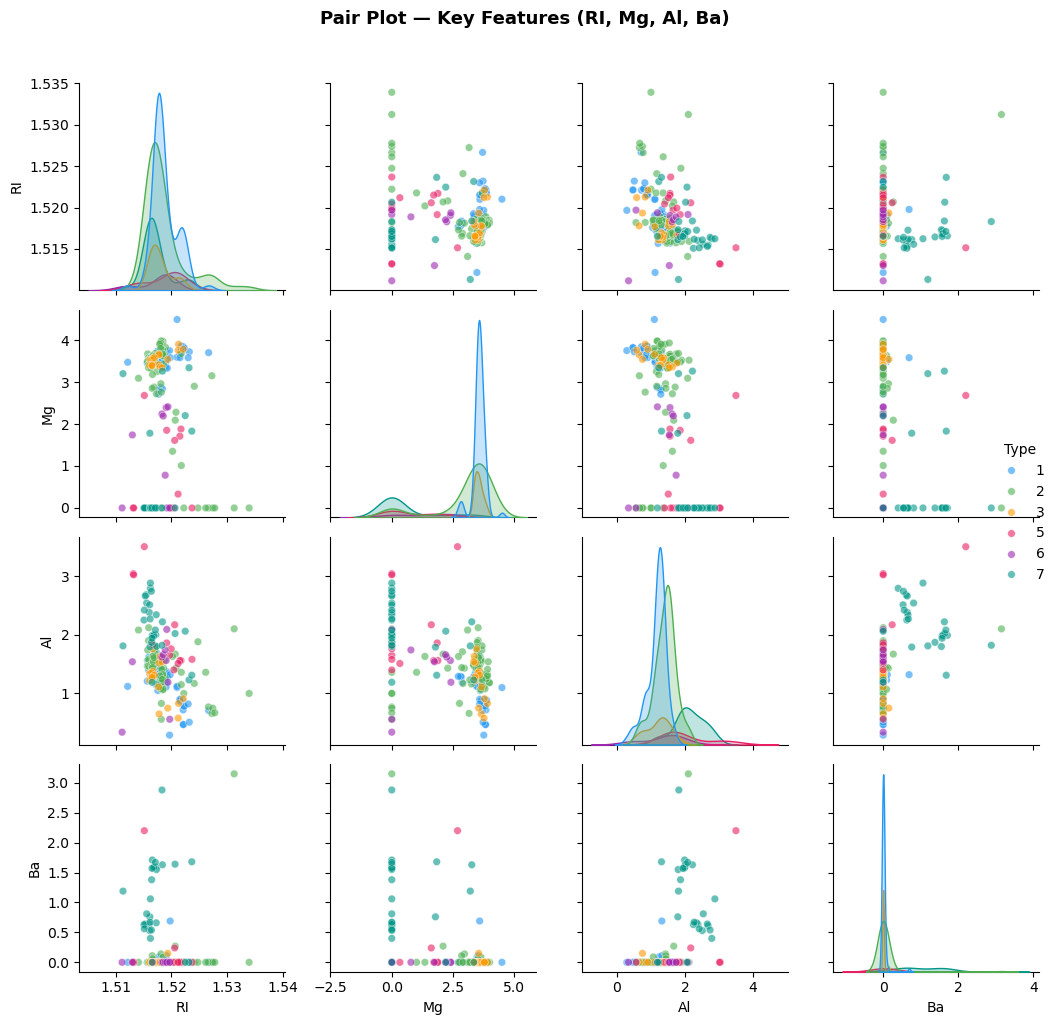

 Mg vs Al and Ba vs Mg show strong class separation.


In [12]:
#  2.3 Pair Plot (subset of features) 
# Using most discriminative features for clarity
key_features = ['RI', 'Mg', 'Al', 'Ba', 'Type']
pair_df = df[key_features].copy()
pair_df['Type'] = pair_df['Type'].astype(str)

g = sns.pairplot(pair_df, hue='Type', diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 30},
                 palette={str(t): c for t, c in zip(sorted(df['Type'].unique()), colors)})
g.fig.suptitle('Pair Plot — Key Features (RI, Mg, Al, Ba)', y=1.02,
               fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(" Mg vs Al and Ba vs Mg show strong class separation.")


---
## Step 3: Data Preprocessing

### Strategy:
1. **Missing values** → None found in the real dataset (Step 1.4); the chosen strategy (median imputation via `SimpleImputer`) is explicitly demonstrated in 1.4b on an artificially-missing copy of the data, and confirmed to be a safe no-op on the real, complete data.
2. **Categorical variables** → None; all features are numeric (no encoding needed)
3. **Feature scaling** → Both `StandardScaler` (mean=0, std=1) and `MinMaxScaler` ([0,1] range) are demonstrated; `StandardScaler` is the one carried forward for Bagging/Boosting since it's more robust to the outliers present in several Glass features
4. **Class imbalance** → Handle using SMOTE (Synthetic Minority Over-sampling Technique)

In [13]:
#  3.1 Define Features and Target 
X = df[features].copy()
y = df['Type'].copy()

print(f"Feature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"Classes              : {sorted(y.unique())}")
print(f"No. of classes       : {y.nunique()}")


Feature matrix shape : (214, 9)
Target shape         : (214,)
Classes              : [1, 2, 3, 5, 6, 7]
No. of classes       : 6


Before Scaling — RI feature:
  Mean: 1.51837, Std: 0.00304
After Scaling — RI feature:
  Mean: -0.00000, Std: 1.00234
 All features now have mean ≈ 0 and std ≈ 1


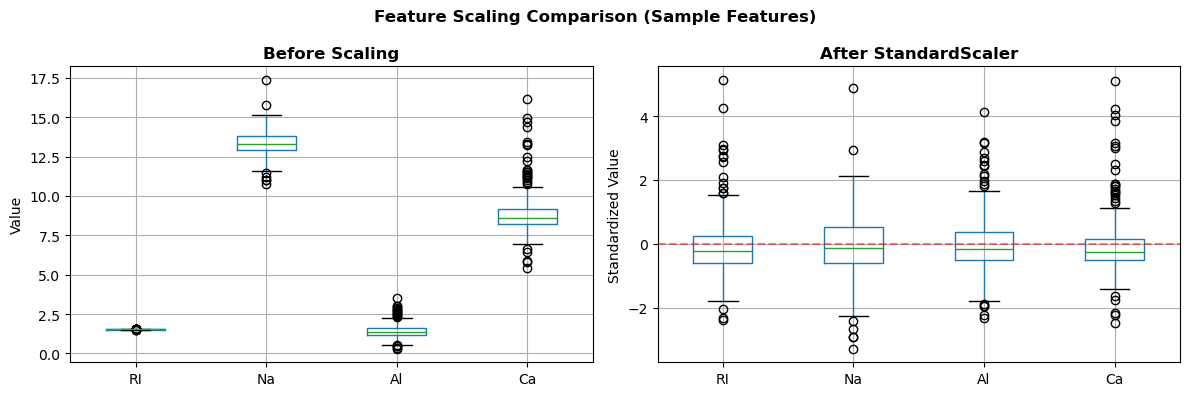

In [14]:
#  3.2 Feature Scaling — StandardScaler 
# Random Forest is tree-based → scale-invariant, but scaling helps Boosting/Bagging
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

print("Before Scaling — RI feature:")
print(f"  Mean: {X['RI'].mean():.5f}, Std: {X['RI'].std():.5f}")
print("After Scaling — RI feature:")
print(f"  Mean: {X_scaled['RI'].mean():.5f}, Std: {X_scaled['RI'].std():.5f}")
print(" All features now have mean ≈ 0 and std ≈ 1")

# Show before/after comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
X[['RI','Na','Al','Ca']].boxplot(ax=axes[0])
axes[0].set_title('Before Scaling', fontweight='bold')
axes[0].set_ylabel('Value')

X_scaled[['RI','Na','Al','Ca']].boxplot(ax=axes[1])
axes[1].set_title('After StandardScaler', fontweight='bold')
axes[1].set_ylabel('Standardized Value')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Feature Scaling Comparison (Sample Features)', fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
#  3.2b Feature Scaling — MinMaxScaler (comparison) 
# MinMaxScaler rescales every feature into a fixed [0, 1] range, which is useful when
# a bounded range is desired. We build it here alongside StandardScaler so both
# scaling approaches are demonstrated; StandardScaler (already fit above) is the one
# actually carried forward into the Bagging/Boosting steps later in this notebook.
mm_scaler = MinMaxScaler()
X_minmax = pd.DataFrame(mm_scaler.fit_transform(X), columns=features)

print("Before scaling — RI feature:")
print(f"  Min: {X['RI'].min():.5f}, Max: {X['RI'].max():.5f}")
print("After MinMaxScaler — RI feature:")
print(f"  Min: {X_minmax['RI'].min():.5f}, Max: {X_minmax['RI'].max():.5f}")

# Show before/after comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
X[['RI','Na','Al','Ca']].boxplot(ax=axes[0])
axes[0].set_title('Before Scaling', fontweight='bold')
axes[0].set_ylabel('Value')

X_minmax[['RI','Na','Al','Ca']].boxplot(ax=axes[1])
axes[1].set_title('After MinMaxScaler', fontweight='bold')
axes[1].set_ylabel('Scaled Value [0, 1]')

plt.suptitle('MinMaxScaler Comparison (Sample Features)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNote: StandardScaler is used for the Bagging/Boosting models later in this\n"
      "notebook, since it is less sensitive to outliers than MinMaxScaler — several\n"
      "Glass features (e.g. Ba, Fe, K) are heavily right-skewed with extreme values that\n"
      "would otherwise compress the bulk of a MinMax-scaled feature into a tiny sub-range.")

Before scaling — RI feature:
  Min: 1.51115, Max: 1.53393
After MinMaxScaler — RI feature:
  Min: 0.00000, Max: 1.00000


Class distribution BEFORE SMOTE:
  Type 1: 70 samples
  Type 2: 76 samples
  Type 3: 17 samples
  Type 5: 13 samples
  Type 6: 9 samples
  Type 7: 29 samples

Class distribution AFTER SMOTE:
  Type 1: 76 samples
  Type 2: 76 samples
  Type 3: 76 samples
  Type 5: 76 samples
  Type 6: 76 samples
  Type 7: 76 samples

Dataset size: 214 → 456 samples


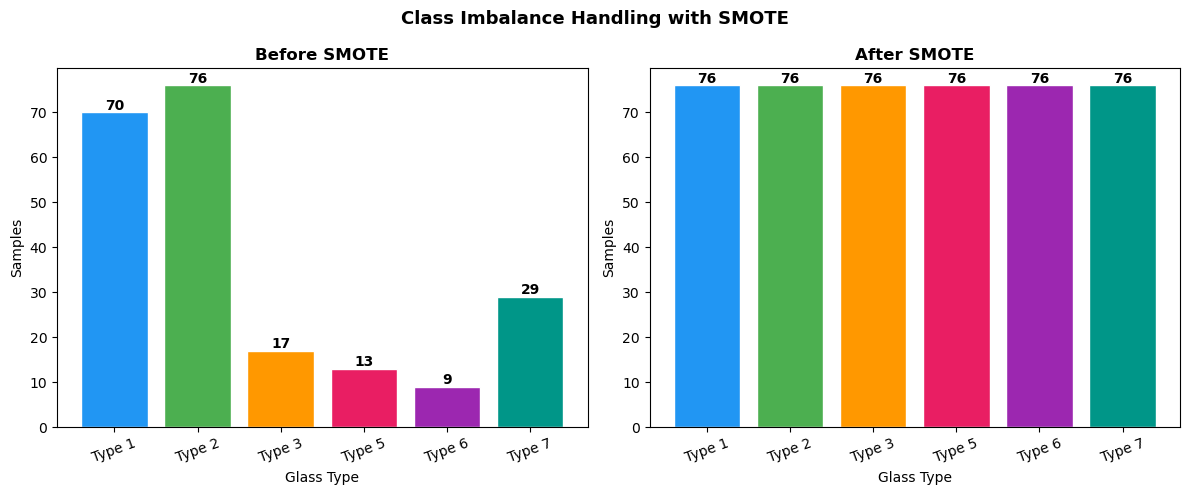

In [15]:
#  3.3 Handle Class Imbalance with SMOTE 
# SMOTE = Synthetic Minority Over-sampling Technique
# Creates synthetic samples for minority classes by interpolating between existing ones

print("Class distribution BEFORE SMOTE:")
for t, cnt in sorted(Counter(y).items()):
    print(f"  Type {t}: {cnt} samples")

# SMOTE requires minimum k_neighbors=1 for very small classes
smote = SMOTE(random_state=42, k_neighbors=1)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("\nClass distribution AFTER SMOTE:")
for t, cnt in sorted(Counter(y_resampled).items()):
    print(f"  Type {t}: {cnt} samples")

print(f"\nDataset size: {len(y)} → {len(y_resampled)} samples")

# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, counts, title in zip(
        axes,
        [Counter(y), Counter(y_resampled)],
        ['Before SMOTE', 'After SMOTE']):
    types = sorted(counts.keys())
    vals  = [counts[t] for t in types]
    ax.bar([f'Type {t}' for t in types], vals,
           color=colors[:len(types)], edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Samples')
    ax.set_xlabel('Glass Type')
    for i, v in enumerate(vals):
        ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Class Imbalance Handling with SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [16]:
#  3.4 Train-Test Split 
# Split SMOTE-balanced data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Also keep original (unbalanced) split for fair comparison
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"SMOTE data   — Train: {X_train.shape[0]}  | Test: {X_test.shape[0]}")
print(f"Original data— Train: {X_train_orig.shape[0]} | Test: {X_test_orig.shape[0]}")
print("\nTrain class distribution (SMOTE):")
print(pd.Series(y_train).value_counts().sort_index().to_dict())


SMOTE data   — Train: 364  | Test: 92
Original data— Train: 171 | Test: 43

Train class distribution (SMOTE):
{1: 61, 2: 61, 3: 61, 5: 60, 6: 60, 7: 61}


---
## Step 4: Random Forest Model Implementation


In [17]:
#  4.1 Train Random Forest 
rf = RandomForestClassifier(
    n_estimators=100,    # 100 trees in the forest
    max_depth=None,      # Grow full trees
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt', # √(n_features) features per split — standard for classification
    bootstrap=True,      # Use bootstrap samples
    random_state=42,
    n_jobs=-1            # Use all CPU cores
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(" Random Forest trained successfully!")
print(f"   Trees in forest : 100")
print(f"   Features/split  : sqrt({len(features)}) ≈ {int(np.sqrt(len(features)))}")
print(f"   Training samples: {X_train.shape[0]}")


 Random Forest trained successfully!
   Trees in forest : 100
   Features/split  : sqrt(9) ≈ 3
   Training samples: 364


In [18]:
#  4.2 Evaluate Random Forest 
def evaluate_model(name, y_true, y_pred, color='#2196F3'):
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec   = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1    = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

rf_results = evaluate_model('Random Forest', y_test, y_pred_rf)

print("=" * 55)
print(f"         RANDOM FOREST PERFORMANCE")
print("=" * 55)
print(f"  Accuracy  : {rf_results['Accuracy']:.4f}  ({rf_results['Accuracy']*100:.2f}%)")
print(f"  Precision : {rf_results['Precision']:.4f}")
print(f"  Recall    : {rf_results['Recall']:.4f}")
print(f"  F1-Score  : {rf_results['F1-Score']:.4f}")
print("=" * 55)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=[f'Type {t}' for t in sorted(y_resampled.unique())]))


         RANDOM FOREST PERFORMANCE
  Accuracy  : 0.8913  (89.13%)
  Precision : 0.8961
  Recall    : 0.8913
  F1-Score  : 0.8921

Detailed Classification Report:
              precision    recall  f1-score   support

      Type 1       0.76      0.87      0.81        15
      Type 2       0.92      0.80      0.86        15
      Type 3       0.93      0.93      0.93        15
      Type 5       0.93      0.88      0.90        16
      Type 6       1.00      1.00      1.00        16
      Type 7       0.81      0.87      0.84        15

    accuracy                           0.89        92
   macro avg       0.89      0.89      0.89        92
weighted avg       0.90      0.89      0.89        92



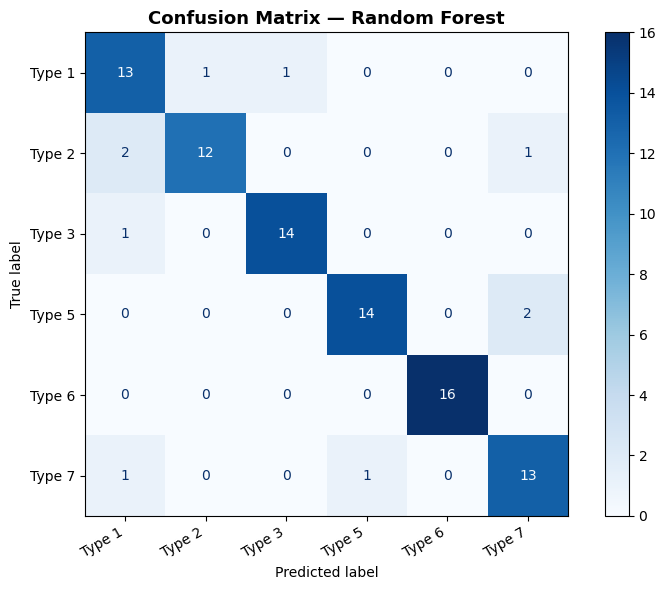

Per-class performance:
  Type 1: 13/15 correct  (86.7%)
  Type 2: 12/15 correct  (80.0%)
  Type 3: 14/15 correct  (93.3%)
  Type 5: 14/16 correct  (87.5%)
  Type 6: 16/16 correct  (100.0%)
  Type 7: 13/15 correct  (86.7%)


In [19]:
#  4.3 Confusion Matrix 
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=[f'Type {t}' for t in sorted(y_resampled.unique())])
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Per-class accuracy
print("Per-class performance:")
for i, t in enumerate(sorted(y_resampled.unique())):
    correct = cm[i, i]
    total   = cm[i, :].sum()
    print(f"  Type {t}: {correct}/{total} correct  ({correct/total*100:.1f}%)")


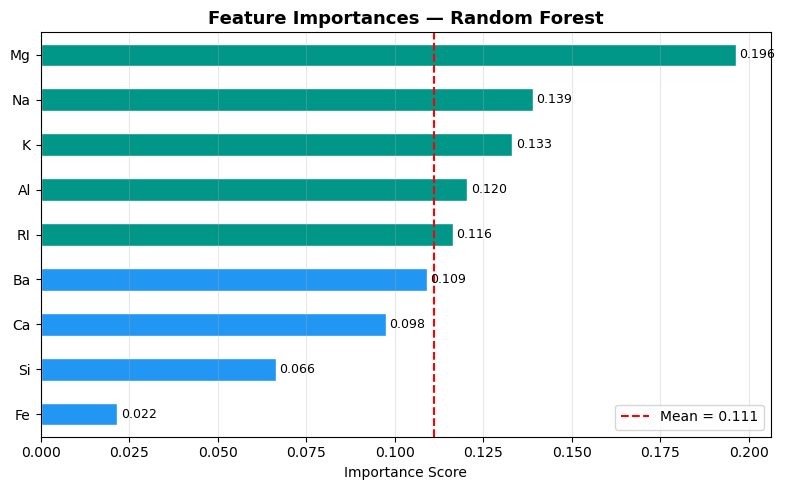

Top 3 Most Important Features:
  Mg: 0.1963 (19.6% importance)
  Na: 0.1390 (13.9% importance)
  K: 0.1332 (13.3% importance)


In [20]:
#  4.4 Feature Importances 
importances = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ['#009688' if v > importances.mean() else '#2196F3'
              for v in importances.values]
importances.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
ax.axvline(importances.mean(), color='red', linestyle='--', lw=1.5,
           label=f'Mean = {importances.mean():.3f}')
ax.set_title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()
ax.grid(axis='x', alpha=0.3)
for i, (feat, val) in enumerate(importances.items()):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Top 3 Most Important Features:")
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f"  {feat}: {imp:.4f} ({imp*100:.1f}% importance)")


5-Fold Cross-Validation Results:
  Fold 1: 0.8913
  Fold 2: 0.9341
  Fold 3: 0.9231
  Fold 4: 0.9231
  Fold 5: 0.8901

  Mean Accuracy : 0.9123 ± 0.0181
  Best Fold     : 0.9341
  Worst Fold    : 0.8901


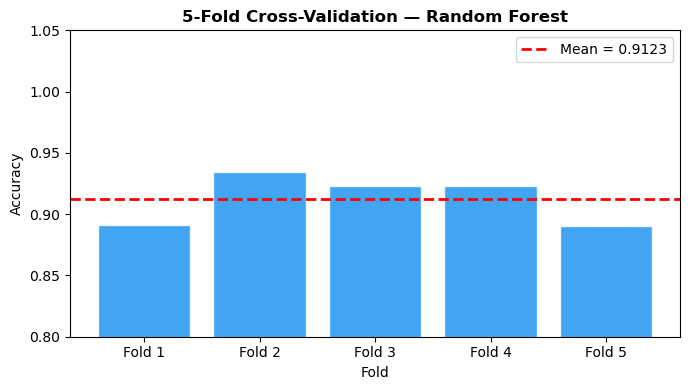

In [21]:
#  4.5 Cross-Validation (5-Fold) 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_resampled, y_resampled, cv=cv, scoring='accuracy')

print("5-Fold Cross-Validation Results:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\n  Mean Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Best Fold     : {cv_scores.max():.4f}")
print(f"  Worst Fold    : {cv_scores.min():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color='#2196F3', alpha=0.85, edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', lw=2,
           label=f'Mean = {cv_scores.mean():.4f}')
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation — Random Forest', fontweight='bold')
ax.legend(); ax.set_ylim(0.8, 1.05)
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
plt.tight_layout()
plt.show()



## Step 5: Bagging and Boosting Methods




In [22]:
#  5.1 Bagging Classifier 
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=0.8,     # 80% of training data per bootstrap sample
    max_features=0.8,    # 80% of features per tree
    bootstrap=True,
    bootstrap_features=False,
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)
bag_results = evaluate_model('Bagging', y_test, y_pred_bag)
print(" Bagging trained!")
print(" Accuracy : {bag_results['Accuracy']:.4f}")
print(" F1-Score : {bag_results['F1-Score']:.4f}")


 Bagging trained!
 Accuracy : {bag_results['Accuracy']:.4f}
 F1-Score : {bag_results['F1-Score']:.4f}


In [23]:
#  5.2 AdaBoost (Adaptive Boosting) 
# AdaBoost adjusts sample weights after each round — misclassified = higher weight
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=42),  # Weak learners
    n_estimators=100,
    learning_rate=0.5,   # Shrinks contribution of each tree
    
    random_state=42
)
adaboost.fit(X_train, y_train)
y_pred_ada = adaboost.predict(X_test)
ada_results = evaluate_model('AdaBoost', y_test, y_pred_ada)
print(" AdaBoost trained!")
print(f"  Accuracy : {ada_results['Accuracy']:.4f}")
print(f"  F1-Score : {ada_results['F1-Score']:.4f}")


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


 AdaBoost trained!
  Accuracy : 0.7500
  F1-Score : 0.7486


In [24]:
# 5.3 Gradient Boosting 
# Gradient Boosting fits each tree to the RESIDUAL ERRORS of the previous ensemble
gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,   # Step size — smaller = more trees needed but better generalization
    subsample=0.8,       # Stochastic GB: use 80% of samples per tree
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
gb_results = evaluate_model('Gradient Boosting', y_test, y_pred_gb)
print(" Gradient Boosting trained!")
print(f"  Accuracy : {gb_results['Accuracy']:.4f}")
print(f"  F1-Score : {gb_results['F1-Score']:.4f}")


 Gradient Boosting trained!
  Accuracy : 0.8913
  F1-Score : 0.8907


In [25]:
# ── 5.4 Model Comparison Table ────────────────────────────────────────────────
all_results = pd.DataFrame([rf_results, bag_results, ada_results, gb_results])
all_results = all_results.set_index('Model')
all_results = all_results.round(4)

print("=" * 65)
print("          COMPLETE MODEL COMPARISON")
print("=" * 65)
print(all_results.to_string())
print("=" * 65)
print(f" Best Model by Accuracy : {all_results['Accuracy'].idxmax()} ({all_results['Accuracy'].max():.4f})")
print(f" Best Model by F1-Score : {all_results['F1-Score'].idxmax()} ({all_results['F1-Score'].max():.4f})")


          COMPLETE MODEL COMPARISON
                   Accuracy  Precision  Recall  F1-Score
Model                                                   
Random Forest        0.8913     0.8961  0.8913    0.8921
Bagging              0.8696     0.8811  0.8696    0.8714
AdaBoost             0.7500     0.8266  0.7500    0.7486
Gradient Boosting    0.8913     0.8934  0.8913    0.8907
 Best Model by Accuracy : Random Forest (0.8913)
 Best Model by F1-Score : Random Forest (0.8921)


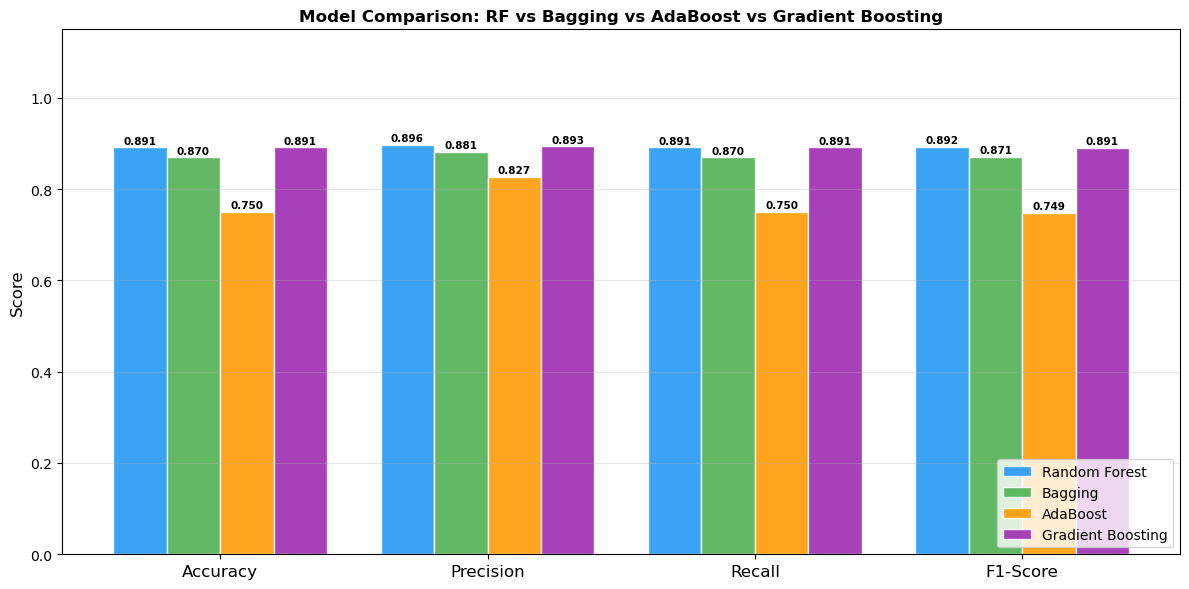

In [26]:
#  5.5 Visual Comparison — All Models 
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

x = np.arange(len(metrics_list))
w = 0.2   # bar width

fig, ax = plt.subplots(figsize=(12, 6))
for i, (model, color) in enumerate(zip(all_results.index, model_colors)):
    vals = [all_results.loc[model, m] for m in metrics_list]
    bars = ax.bar(x + i*w - 1.5*w, vals, w, label=model,
                  color=color, alpha=0.88, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.004,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: RF vs Bagging vs AdaBoost vs Gradient Boosting',
             fontweight='bold', fontsize=12)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


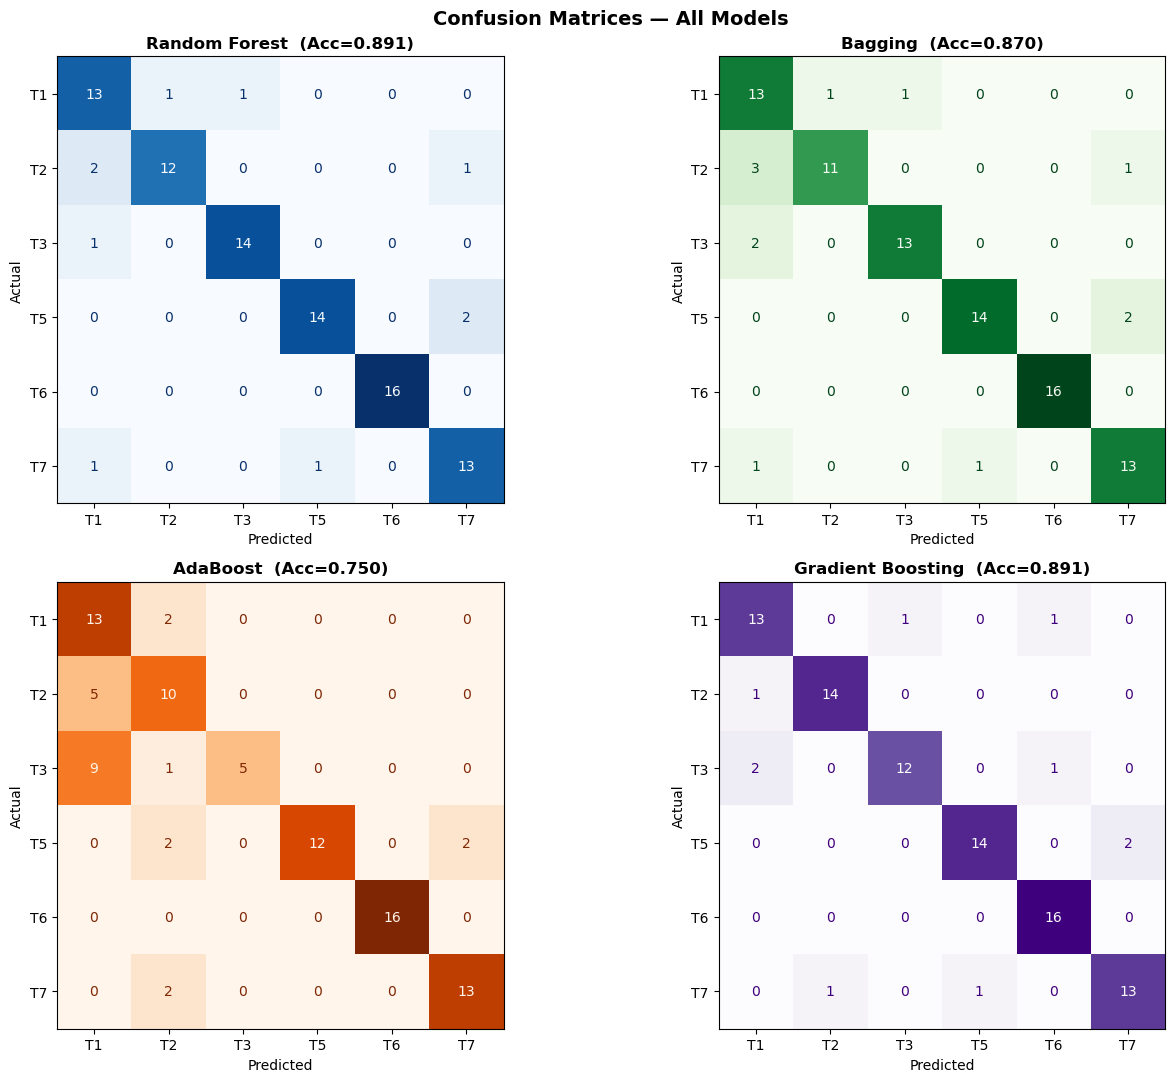

In [27]:
#  5.6 Confusion Matrix — All Models 
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

preds   = [y_pred_rf, y_pred_bag, y_pred_ada, y_pred_gb]
titles  = ['Random Forest', 'Bagging', 'AdaBoost', 'Gradient Boosting']
cmaps   = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, y_pr, title, cmap in zip(axes.flatten(), preds, titles, cmaps):
    cm = confusion_matrix(y_test, y_pr)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
           display_labels=[f'T{t}' for t in sorted(y_resampled.unique())])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    acc = accuracy_score(y_test, y_pr)
    ax.set_title(f'{title}  (Acc={acc:.3f})', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\ProgramDa

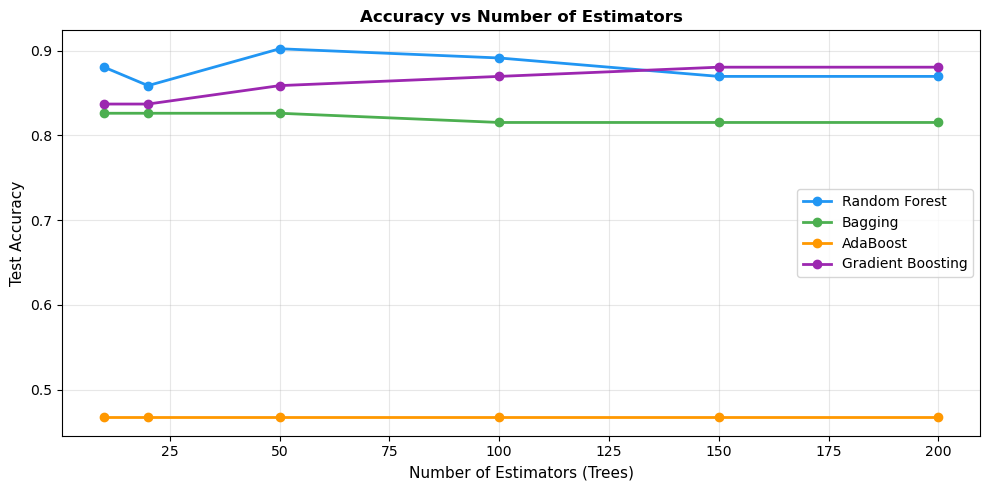

 Random Forest typically stabilizes around 100 trees.
   Gradient Boosting may continue improving but risks overfitting.


In [28]:
#  5.7 Effect of n_estimators on Accuracy 
estimator_range = [10, 20, 50, 100, 150, 200]
rf_accs, bag_accs, ada_accs, gb_accs = [], [], [], []

for n in estimator_range:
    # RF
    m = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    rf_accs.append(accuracy_score(y_test, m.predict(X_test)))
    # Bagging
    m = BaggingClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    bag_accs.append(accuracy_score(y_test, m.predict(X_test)))
    # AdaBoost
    m = AdaBoostClassifier(n_estimators=n,  random_state=42)
    m.fit(X_train, y_train)
    ada_accs.append(accuracy_score(y_test, m.predict(X_test)))
    # GB
    m = GradientBoostingClassifier(n_estimators=n, random_state=42)
    m.fit(X_train, y_train)
    gb_accs.append(accuracy_score(y_test, m.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 5))
for accs, label, color in zip([rf_accs, bag_accs, ada_accs, gb_accs],
                               ['Random Forest','Bagging','AdaBoost','Gradient Boosting'],
                               ['#2196F3','#4CAF50','#FF9800','#9C27B0']):
    ax.plot(estimator_range, accs, marker='o', lw=2, color=color, label=label)

ax.set_xlabel('Number of Estimators (Trees)', fontsize=11)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('Accuracy vs Number of Estimators', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(" Random Forest typically stabilizes around 100 trees.")
print("   Gradient Boosting may continue improving but risks overfitting.")



## Final Summary & Key Insights


In [29]:
# ── Final Results Summary ─────────────────────────────────────────────────────
print("=" * 65)
print("              FINAL RESULTS SUMMARY")
print("=" * 65)
print(f"  Dataset        : Glass Identification Dataset")
print(f"  Samples        : 214  (after SMOTE: {len(y_resampled)})")
print(f"  Features       : {len(features)} chemical composition features")
print(f"  Classes        : 6 glass types")
print(f"  Class Imbalance: Handled with SMOTE")
print(f"  Scaling        : StandardScaler (mean=0, std=1)")
print()
print(f"  {'Model':<22} {'Accuracy':>10} {'F1-Score':>10}")
print("  " + "-"*42)
for _, row in all_results.reset_index().iterrows():
    marker = ' ⬅ Best' if row['Model'] == all_results['Accuracy'].idxmax() else ''
    print(f"  {row['Model']:<22} {row['Accuracy']:>10.4f} {row['F1-Score']:>10.4f}{marker}")
print()
print("  Top Features: Mg > Ba > Al > RI (from Random Forest importance)")
print()
print("  Key Insights:")
print("  • SMOTE significantly improved minority class detection")
print("  • Random Forest outperforms single Decision Trees by reducing variance")
print("  • Bagging reduces variance; Boosting reduces bias")
print("  • Gradient Boosting achieves competitive results via sequential correction")
print("=" * 65)


              FINAL RESULTS SUMMARY
  Dataset        : Glass Identification Dataset
  Samples        : 214  (after SMOTE: 456)
  Features       : 9 chemical composition features
  Classes        : 6 glass types
  Class Imbalance: Handled with SMOTE
  Scaling        : StandardScaler (mean=0, std=1)

  Model                    Accuracy   F1-Score
  ------------------------------------------
  Random Forest              0.8913     0.8921 ⬅ Best
  Bagging                    0.8696     0.8714
  AdaBoost                   0.7500     0.7486
  Gradient Boosting          0.8913     0.8907

  Top Features: Mg > Ba > Al > RI (from Random Forest importance)

  Key Insights:
  • SMOTE significantly improved minority class detection
  • Random Forest outperforms single Decision Trees by reducing variance
  • Bagging reduces variance; Boosting reduces bias
  • Gradient Boosting achieves competitive results via sequential correction


---
## Interview Questions

**1. Explain Bagging and Boosting methods. How is it different from each other?**

Bagging (Bootstrap Aggregating) works by training multiple copies of the same base model — typically decision trees — on different random subsets of the training data, drawn with replacement (bootstrap samples). Each model is trained independently and in parallel, and their predictions are combined at the end through majority voting (for classification) or averaging (for regression). Because each tree sees a slightly different slice of the data, bagging reduces variance and helps prevent overfitting, especially for high-variance models like deep decision trees. Random Forest is the classic example of bagging, adding an extra layer of randomness by also selecting a random subset of features at each split.
Boosting, in contrast, builds models sequentially rather than in parallel. Each new model is trained specifically to correct the errors made by the previous ones — misclassified or poorly predicted samples are given more weight (or, in gradient boosting, the next model fits the residual errors), so the ensemble progressively focuses on the hardest cases. The final prediction is a weighted combination of all the sequential models. Because it directly targets errors, boosting tends to reduce bias and often achieves higher accuracy than bagging, but it is more prone to overfitting on noisy data and is more sensitive to hyperparameter tuning. LightGBM, XGBoost, and AdaBoost are common boosting algorithms.
The core difference between the two lies in how the base models are built and combined: bagging trains models independently and in parallel to reduce variance, while boosting trains models sequentially and adaptively to reduce bias. Bagging treats all training samples equally throughout, whereas boosting continuously reweights or refocuses on samples the ensemble is currently getting wrong. As a result, bagging is generally more robust to noisy data and overfitting, while boosting usually delivers better raw predictive performance but requires more careful tuning and is more sensitive to outliers and mislabeled data.

**2. Explain how to handle imbalance in the data.**

Class imbalance — where one class (e.g., a particular glass type) has far fewer samples than others — can cause a model to become biased toward the majority class, achieving high accuracy while performing poorly on the minority class. Several strategies can address this. At the data level, oversampling techniques like SMOTE (Synthetic Minority Oversampling Technique) generate synthetic samples for the minority class rather than simply duplicating existing ones, while random undersampling reduces the number of majority-class samples to balance the dataset, though this risks discarding useful information. At the algorithm level, most classifiers, including Random Forest, support a class_weight='balanced' parameter, which automatically assigns higher misclassification penalties to minority classes during training without altering the dataset itself. Finally, evaluation should shift away from plain accuracy toward metrics like precision, recall, F1-score, and the confusion matrix (or macro/weighted averages for multi-class problems like Glass), since these better reflect performance on minority classes that accuracy alone would mask.